In [1]:
from odc import stac as odc_stac
from pystac_client import Client
import xarray as xr
import xarray as xr
import numpy as np 

In [20]:
eodc_catalog = Client.open(
    "https://stac.eodc.eu/api/v1",
)

collection = "climatedt-austria"

In [23]:
search = eodc_catalog.search(collections=[collection])
for item in search.items():
    print(item.id)

IFS-NEMO-ScenarioMIP-snowDepth
IFS-NEMO-ScenarioMIP
ICON-ScenarioMIP
IFS-FESOM-story-nudging-Tplus2
IFS-FESOM-story-nudging-hist
IFS-FESOM-story-nudging-cont
ICON-CMIP6
IFS-NEMO-HighResMIP
IFS-NEMO-CMIP6


Set your group and get some information about the item/asset

In [24]:
item = next(
    eodc_catalog.search(collections=[collection], ids=["IFS-FESOM-story-nudging-cont"]).items()
)
print(item.properties)

print(item.assets.keys())


asset = item.assets['data']
# get url
store_url = asset.href
print(store_url)
print(asset.extra_fields)

{'title': 'IFS-FESOM story-nudging cont', 'description': 'Model: IFS-FESOM \nActivity: story-nudging \nExperiment: cont \n Resolution: high', 'end_datetime': '2023-12-31T00:00:00Z', 'start_datetime': '2017-01-01T00:00:00Z'}
dict_keys(['data'])
https://objects.eodc.eu/68e13833a1624f43ba2cac01376a18af:destine-climate-dt/Austria/climate-dt-austria.zarr
{'bands': [{'name': '2 metre temperature', 'description': 'Near-surface (usually, 2 meter) air temperature'}, {'name': 'Total precipitation', 'description': 'Represents the amount of water (rain, snow, etc.) as the depth of liquid water if it were all melted and spread evenly.'}], 'xarray:open_zarr_kwargs': {'group': 'IFS-FESOM_sfc_story-nudging_cont', 'zarr_format': 3, 'consolidated': True}}


Open data with xarray

In [25]:
coords = xr.open_zarr(
    store_url,
    **asset.extra_fields["xarray:open_zarr_kwargs"]
)

print(coords)

<xarray.Dataset> Size: 2GB
Dimensions:    (t: 61344, pointid: 2063)
Coordinates:
  * t          (t) datetime64[ns] 491kB 2017-01-01 ... 2023-12-31T23:00:00
  * pointid    (pointid) int64 17kB 3 0 2 1 7 5 ... 2062 2063 2064 2065 2066
    latitude   (pointid) float64 17kB dask.array<chunksize=(2063,), meta=np.ndarray>
    longitude  (pointid) float64 17kB dask.array<chunksize=(2063,), meta=np.ndarray>
Data variables:
    2t         (t, pointid) float64 1GB dask.array<chunksize=(61344, 100), meta=np.ndarray>
    tp         (t, pointid) float64 1GB dask.array<chunksize=(61344, 100), meta=np.ndarray>


Plot all points on a map

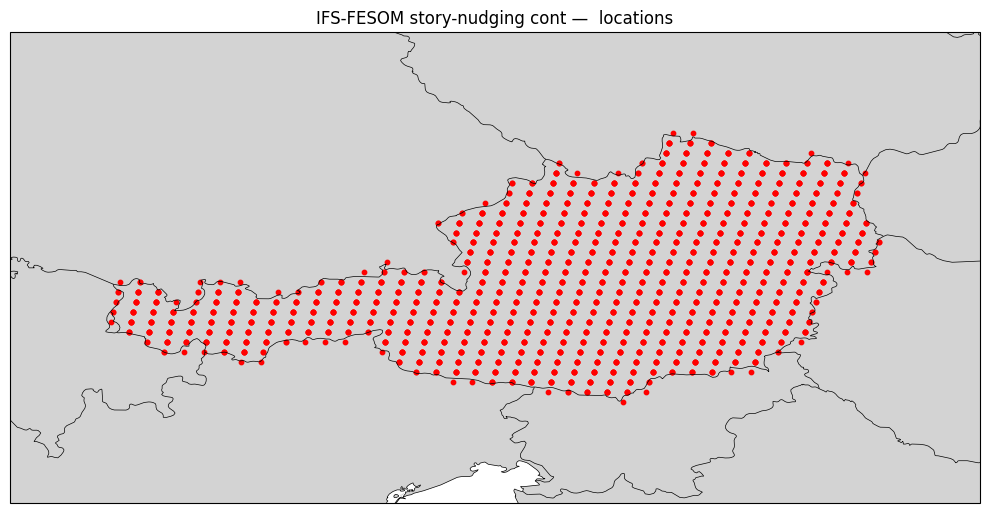

In [26]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



lats = coords["latitude"].values
lons = coords["longitude"].values

fig, ax = plt.subplots(figsize=(10, 7),
                       subplot_kw={"projection": ccrs.PlateCarree()})

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(lons, lats, s=10, c="red", transform=ccrs.PlateCarree())

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1],
              crs=ccrs.PlateCarree())

plt.title(f"{asset.title} —  locations")
plt.tight_layout()
plt.show()

Create a plot of both data variables at a specific bbox for 2023

Points in subset: 4


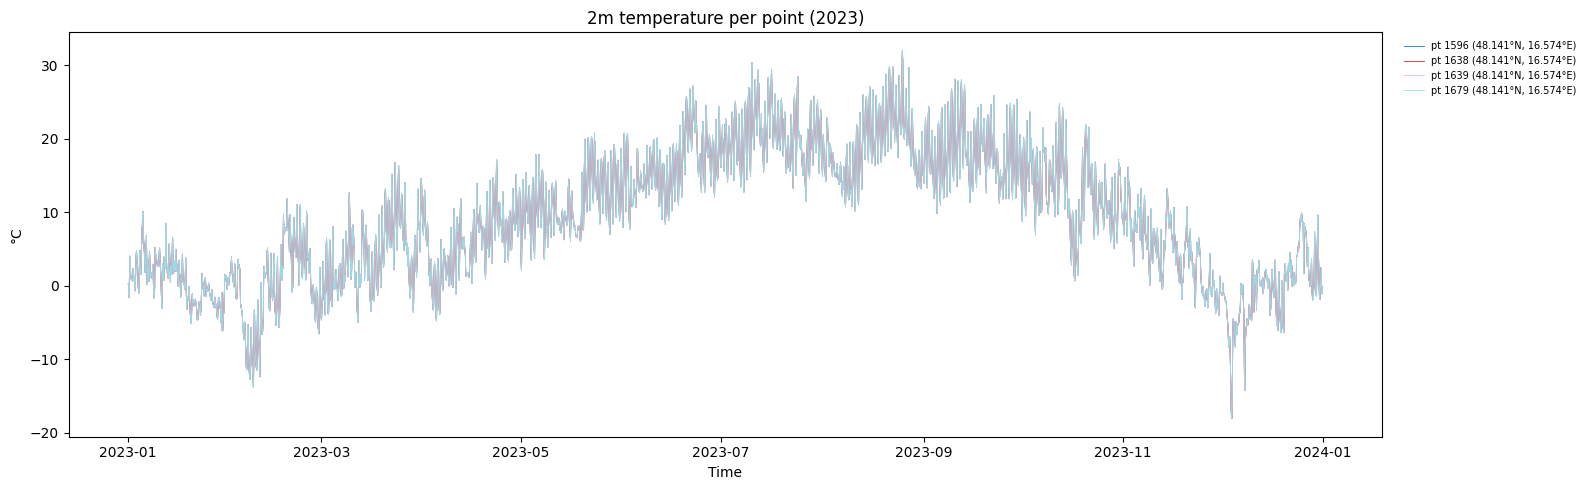

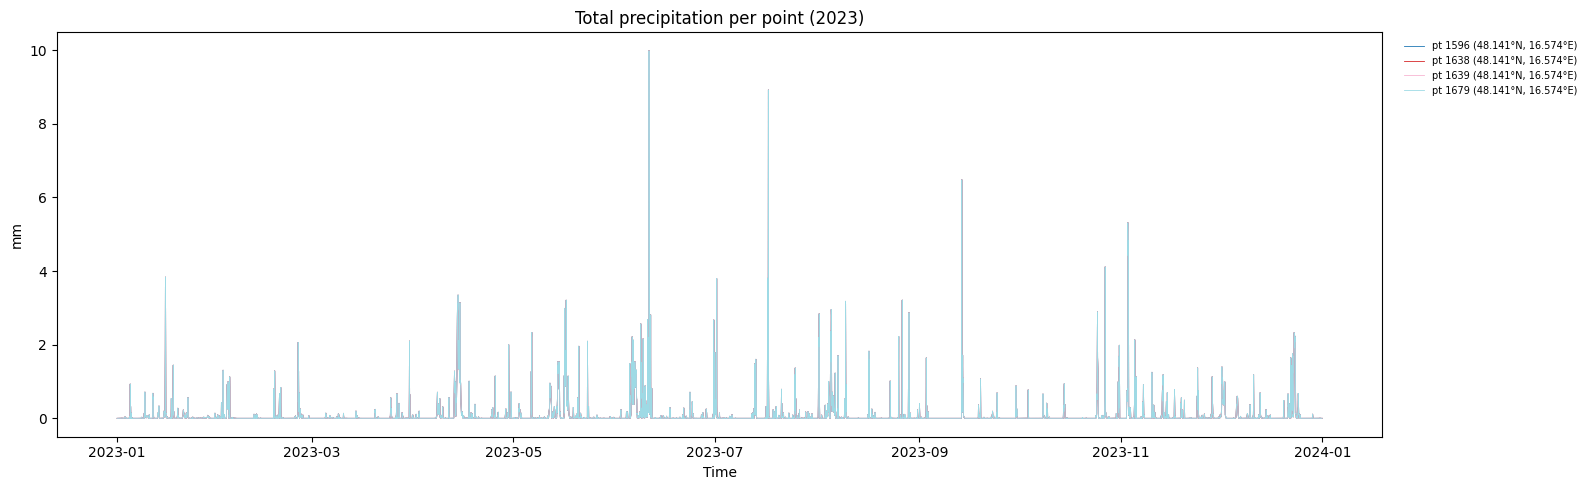

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

lon_min, lat_min, lon_max, lat_max = 16.472454,48.114537,16.646519,48.209918

mask = (
    (coords.longitude >= lon_min) & (coords.longitude <= lon_max) &
    (coords.latitude  >= lat_min) & (coords.latitude  <= lat_max)
)
ds_sub = coords.sel(pointid=coords.pointid[mask.values])
ds_2023 = ds_sub.sel(t=slice("2023-01-01", "2023-12-31"))

n_points = ds_2023.sizes["pointid"]
print(f"Points in subset: {n_points}")

data_2t = ds_2023["2t"].compute() - 273.15   # → °C
data_tp = ds_2023["tp"].compute() * 1000      # → mm

times = ds_2023.t.values
colors = cm.tab20(np.linspace(0, 1, n_points))

fig, ax = plt.subplots(figsize=(16, 5))
for i, pid in enumerate(ds_2023.pointid.values):
    lat = float(ds_2023.latitude.sel(pointid=pid).values)
    lon = float(ds_2023.longitude.sel(pointid=pid).values)
    ax.plot(times, data_2t.sel(pointid=pid).values,
            color=colors[i], linewidth=0.6,
            label=f"pt {pid} ({lat:.3f}°N, {lon:.3f}°E)")

ax.set_title("2m temperature per point (2023)")
ax.set_ylabel("°C")
ax.set_xlabel("Time")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
for i, pid in enumerate(ds_2023.pointid.values):
    lat = float(ds_2023.latitude.sel(pointid=pid).values)
    lon = float(ds_2023.longitude.sel(pointid=pid).values)
    ax.plot(times, data_tp.sel(pointid=pid).values,
            color=colors[i], linewidth=0.6,
            label=f"pt {pid} ({lat:.3f}°N, {lon:.3f}°E)")

ax.set_title("Total precipitation per point (2023)")
ax.set_ylabel("mm")
ax.set_xlabel("Time")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

Create a plot of both data variables for the spatial mean at a specific bbox

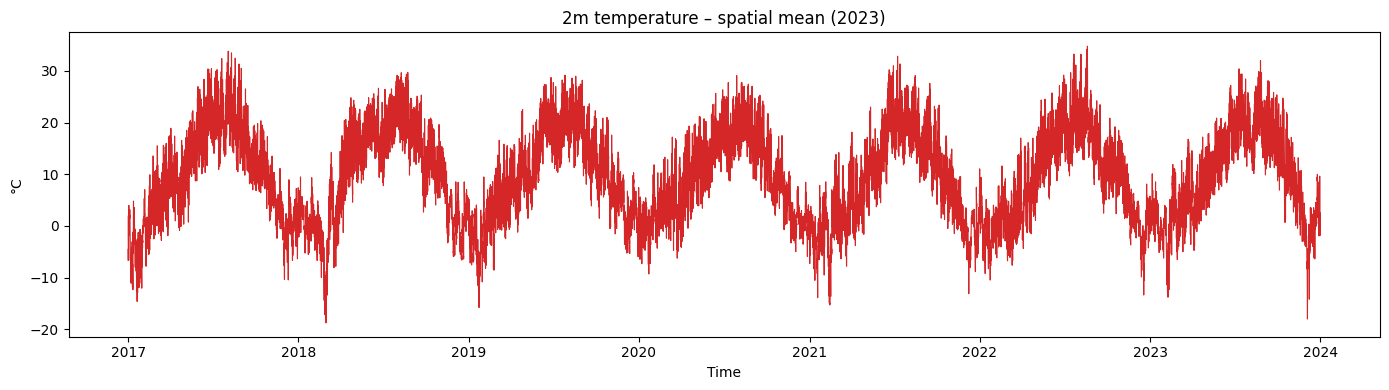

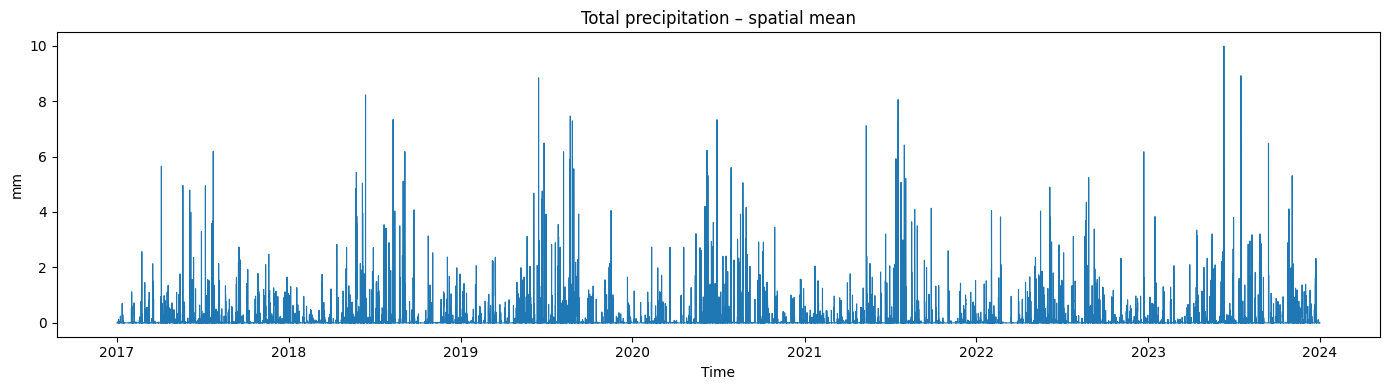

In [19]:
import matplotlib.pyplot as plt
import pandas as pd


lon_min, lat_min, lon_max, lat_max = 16.472454,48.114537,16.646519,48.209918

mask = (
    (coords.longitude >= lon_min) & (coords.longitude <= lon_max) &
    (coords.latitude  >= lat_min) & (coords.latitude  <= lat_max)
)
ds_sub = coords.sel(pointid=coords.pointid[mask.values])


# ds_2023 = ds_sub.sel(t=slice("2023-01-01", "2023-12-31"))


mean_2t = ds_sub["2t"].mean(dim="pointid").compute()
mean_tp = ds_sub["tp"].mean(dim="pointid").compute()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mean_2t.t, mean_2t.values - 273.15, linewidth=0.8, color="tab:red")
ax.set_title("2m temperature – spatial mean (2023)")
ax.set_ylabel("°C")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mean_tp.t, mean_tp.values * 1000, linewidth=0.8, color="tab:blue")
ax.set_title("Total precipitation – spatial mean")
ax.set_ylabel("mm")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()